# 💓 Hypertension Risk Atlas 🗺️

**ADS-599 Capstone Project — University of San Diego**
**Project Group 2:** Nancy Walker & Michelle Wang

> ⚠️ **Prerequisite Note:** Before running this notebook, please ensure you have activated your virtual environment, installed the dependencies via `pip install -r requirements.txt`, and executed the main pipeline using `python main.py`. This ensures all required model artifacts, datasets, and figures are available.

📖 Table of Contents 

1. [Introduction](#1-Introduction)
2. [Research Hypotheses](#2-Research-hypotheses)
3. [Install Dependencies](#3-install-dependencies)
4. [Ingest Master Dataset](#4-ingest-master-dataset)
5. [Exploratory Data Analysis & Multicollinearity](#5-exploratory-data-analysis--multicollinearity)
6. [Feature Engineering](#6-feature-engineering)
7. [Modeling & Evaluation](#7-modeling--evaluation) 
8. [SHAP Interpretability & Geographically Varying Drivers](#8-shap-interpretability--geographically-varying-drivers)
9. [Conclusion & Next Steps](#9-conclusion--next-steps)

## 1. Introduction

Hypertension remains a leading cause of premature death and exhibits distinct, persistent spatial clustering driven by underlying Social Determinants of Health (SDOH). Traditional public health interventions largely rely on reactive, lagging-data models to allocate limited prevention and screening resources.

To address this limitation, this project shifts toward a proactive modeling strategy, by developing an interpretable machine learning framework to predict county-level hypertension prevalence across the United States using place-based social and environmental determinants, while surfacing local SHAP-driven insights to explain the specific structural drivers behind each county's risk profile.

## 2. Research Hypotheses

**Research Hypotheses:**

1. **Predictive Drivers:** Structural neighborhood features—specifically vehicle access barriers and food-desert density—will rank among the strongest predictors of county-level hypertension prevalence, as quantified by permutation importance and SHAP attribution across the full predictor set.

2. **Dimensionality & Multicollinearity Control:** Deploying a regularized feature-pruning framework (Lasso/PCA) to isolate dense socio-environmental vectors will effectively mitigate multicollinearity among food-access indicators, enabling regression ensembles (XGBoost and Random Forest) to achieve superior predictive accuracy ($R^2$, RMSE, and MAE) over a traditional linear regression baseline on a held-out test set.

3. **Heterogeneity & Localized Etiology:** SHAP-based feature importance will uncover geographically varying drivers of health disparities, demonstrating that hypertension etiology is non-uniform and highly dependent on localized structural conditions.

## 3. Install Dependencies

In [28]:
# Install Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import sys
from pathlib import Path
import plotly.express as px
from scipy.stats import spearmanr

# --- Jupyter Path Setup ---
try: 
    ROOT_DIR = Path.cwd().resolve()
    if ROOT_DIR.name == "notebooks":
        ROOT_DIR = ROOT_DIR.parent
except NameError:
    ROOT_DIR = Path(".").reslive()

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

# Project modules and Custom Paths 
from paths import DATA_FINAL, DATA_PROCESSED, validate_and_alert
from utils import variable_color

# Machine Learning and Skit-learn Libraries
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from xgboost import XGBRegressor

import warnings
import sys
warnings.filterwarnings('ignore')

## Ingest Master Dataset

*For full details on Data Ingestion visit folder `notebooks/01_DataIngestion`*

### 📊 Data Sources

All four sources are public, free, and joined on the 5-digit county FIPS / GEOID.

| Source | Contribution | Size (raw) | Access |
|--------|-------------|------------|--------|
| CDC PLACES | Health outcomes incl. target (hypertension prevalence) | 3,144 counties × 24 cols | Socrata API (RSocrata) / download; no key |
| USDA Food Access Research Atlas | Food environment & access indicators | 72,531 tracts × 147 cols | Direct download; no key |
| U.S. Census Bureau (ACS) | Socioeconomic context (income, poverty, housing) | 6,444 records × 5 cols | Census Data API; free key |
| County Health Rankings (CHR&R) | Social & clinical community health metrics | 3,204 counties × 796 cols | Download / `countyhealthR`; no key |

**Data Validation & Provenance Note:** Prior to the master dataset merge, all source tables were independently validated for row counts, column counts, and missingness tiers. Datasets were subsequently joined on county GEOID to produce the final analytic table. Detailed validation reports for each individual data source are archived in the `notebooks/02_validation` directory.

**Active analytic dataset (`master_dataset_all_variables.csv`):** three sources — CDC PLACES, USDA FARA, and Census ACS — standardized to county-level GEOID and merged into a single table of **3,231 rows × 120 columns**. Target variable: county-level hypertension prevalence (**BPHIGH**), observed for 2,956 counties (91.5%), which is the effective sample size for modeling.

**CHR&R (not merged):** its 796 raw columns carry high per-column missingness (suppression flags) and substantial redundancy, so it requires a dedicated feature-selection pass before it can be folded into the master table without overwhelming the model. A specific release year is pinned for reproducibility (CHR&R funding concludes December 2026). Dataset used in dashboard only. 

In [29]:
# Load data
data_path = DATA_PROCESSED / "master_dataset_all_variables.csv"
validate_and_alert(data_path, "Master Dataset", "Run Data Ingestion and Cleaning scripts.")
    
FIPS_COL = "fipscode"
TARGET_COL = "BPHIGH"
df = pd.read_csv(data_path, dtype={FIPS_COL: str}, low_memory=False)

df.head().T

✅ Data found for Master Dataset. Proceeding...


,0,1,2,3,4
fipscode,01001,01003,01005,01007,01009
locationname,Autauga,Baldwin,Barbour,Bibb,Blount
stateabbr,AL,AL,AL,AL,AL
ACCESS2,9.1,8.8,14.8,13.0,12.0
BPHIGH,38.2,37.0,45.4,42.4,36.0
...,...,...,...,...,...
PCTGQTRS,0.833776,1.265739,11.629093,9.705433,0.853076
State,Alabama,Alabama,Alabama,Alabama,Alabama
County,Autauga County,Baldwin County,Barbour County,Bibb County,Blount County
poverty_count,6275.0,24819.0,4746.0,4258.0,8269.0


## 5. Exploratory Data Analysis & Multicollinearity

*For full details on Exploratory Data Analysis visit folder `notebooks/03_EDA/eda_master.ipynb`*

In [30]:
df.shape

(3231, 120)

The table lands at 3,231 rows × 120 columns. The column count tracks a three-source merge (CDC PLACES, USDA FARA, Census ACS) — CHR&R was not folded in, which is why this is far leaner than the 872-column draft from the earlier four-source attempt. The row count runs slightly above the ~3,142 U.S. counties.

In [31]:
pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": round(df.isnull().mean() * 100, 2)
}).sort_values("Missing Count", ascending=False)

,Missing Count,Missing %
LACKTRPT,932,28.85
EMOTIONSPT,932,28.85
LONELINESS,932,28.85
HOUSINSECU,932,28.85
FOODINSECU,932,28.85
...,...,...
SLEEP,88,2.72
stateabbr,88,2.72
poverty_count,11,0.34
median_income,11,0.34


In [32]:
missing_pct = df.isnull().mean() * 100
pd.cut(missing_pct, bins=[-1, 0, 5, 20, 40, 60, 100],
       labels=["0%", "<5%", "5-20%", "20-40%", "40-60%", ">60%"]).value_counts()

<5%       100
5-20%      13
20-40%      6
0%          1
40-60%      0
>60%        0
Name: count, dtype: int64

In the master dataset, missing data isn't a real problem: 100 of the 120 columns are missing less than 5% of their values, and only 6 fall in the 20–40% range. Nothing crosses the 60% threshold that would justify dropping a column outright. In practical terms, every column here has enough real data to work with — the right move is to impute the gaps, not remove columns.

[⬆ Back to Top](#top)

### 5.1 Target Variable Analysis

BPHIGH — county-level hypertension prevalence from CDC PLACES  is the variable this whole project predicts, so it earns a dedicated look before anything else gets built on top of it. Every later modeling choice, from whether a plain linear baseline is reasonable to which error metric to optimize, hinges on what this distribution actually looks like. Here we check its central tendency and spread, whether the shape is close to normal or skewed enough to warrant a transformation, and whether the range of values (min/max) is plausible for a prevalence percentage rather than a sign of a leftover data issue.

In [33]:
TARGET_COL = "BPHIGH"
df[TARGET_COL].describe()

count    2956.000000
mean       33.537483
std         4.654139
min        21.000000
25%        30.100000
50%        32.800000
75%        36.300000
max        53.100000
Name: BPHIGH, dtype: float64

Mean (33.5%) and median (32.8%) sit close together, indicating a fairly balanced distribution. And the range (21%–53.1%) is realistic for county-level hypertension prevalence — all values fall within sensible bounds, with no negatives, zeros, or impossible percentages that would signal a data problem.

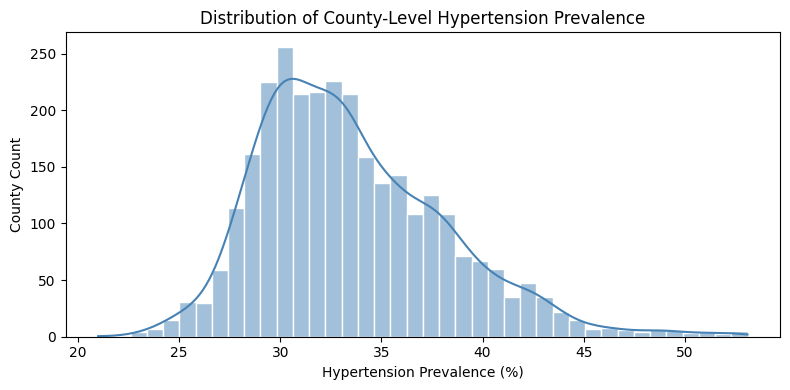

In [34]:
# Generate Figure 1: Target Variable Distribution
fig1, ax1 = plt.subplots(figsize=(8, 4))
sns.histplot(df[TARGET_COL].dropna(), bins=40, kde=True, color="steelblue", edgecolor="white", ax=ax1)
ax1.set_xlabel("Hypertension Prevalence (%)")
ax1.set_ylabel("County Count")
ax1.set_title("Distribution of County-Level Hypertension Prevalence")
plt.tight_layout()

plt.show()

The histogram shows a single mode with a longer right tail rather than a sharp cutoff — consistent with the mean sitting slightly above the median above. Worth quantifying that tail directly rather than eyeballing it.

In [35]:
df[TARGET_COL].skew()

np.float64(0.8330842827589355)

A skew of 0.83 confirms a moderate right skew — noticeable, but nowhere near severe (values above ~1 typically prompt a transformation outright). A log-transform is worth testing as a candidate during modeling rather than something this notebook needs to decide now.
A skewness of 0.83 confirms a moderate right skew — enough to notice, not enough to force a transformation (the usual rule of thumb reserves that for values above 1). The practical takeaway: test a log-transformed target as a modeling candidate, but no decision is needed in this notebook.

The skewness value of 0.83 quantifies what the histogram showed: a moderate right skew. As a rule of thumb, skewness between 0.5 and 1 is considered moderate, while values above 1 usually call for a transformation. Since BPHIGH sits below that threshold, a log-transform is optional rather than required.

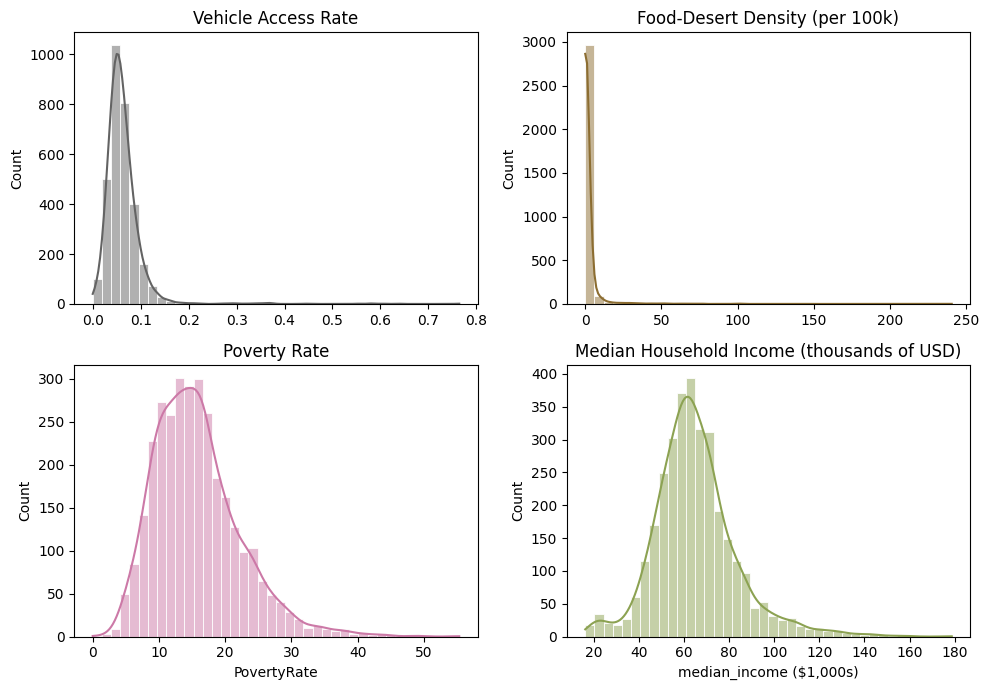

In [36]:
# Generate Figure 2: Key Predictor Distributions (2x2 Grid)
vehicle_access_rate = df["TractHUNV"] / df["OHU2010"]
food_desert_density = df["LILATracts_1And10"] / df["Pop2010"] * 100_000

fig_grid, axes = plt.subplots(2, 2, figsize=(10, 7))
sns.histplot(vehicle_access_rate.dropna(), bins=40, kde=True,
             color=variable_color("vehicle_access_rate"),
             edgecolor="white", ax=axes[0, 0])
axes[0, 0].set_title("Vehicle Access Rate")

sns.histplot(food_desert_density.dropna(), bins=40, kde=True,
             color=variable_color("food_desert_density"),
             edgecolor="white", ax=axes[0, 1])
axes[0, 1].set_title("Food-Desert Density (per 100k)")

sns.histplot(df["PovertyRate"].dropna(), bins=40, kde=True,
             color=variable_color("PovertyRate"),
             edgecolor="white", ax=axes[1, 0])
axes[1, 0].set_title("Poverty Rate")

sns.histplot(df["median_income"] / 1_000, bins=40, kde=True,
             color=variable_color("median_income"),
             edgecolor="white", ax=axes[1, 1])
axes[1, 1].set_title("Median Household Income (thousands of USD)")
axes[1, 1].set_xlabel("median_income ($1,000s)")

plt.tight_layout()

plt.show()

Individual analysis of key predictors revealed pronounced right skewness in the food-desert density measure and household vehicle-access rate, while poverty rate demonstrated moderate skewness. Conversely, median household income displayed a nearly symmetric distribution centered around $60,000. Data quality checks confirmed the absence of implausible values or anomalous distributional patterns.

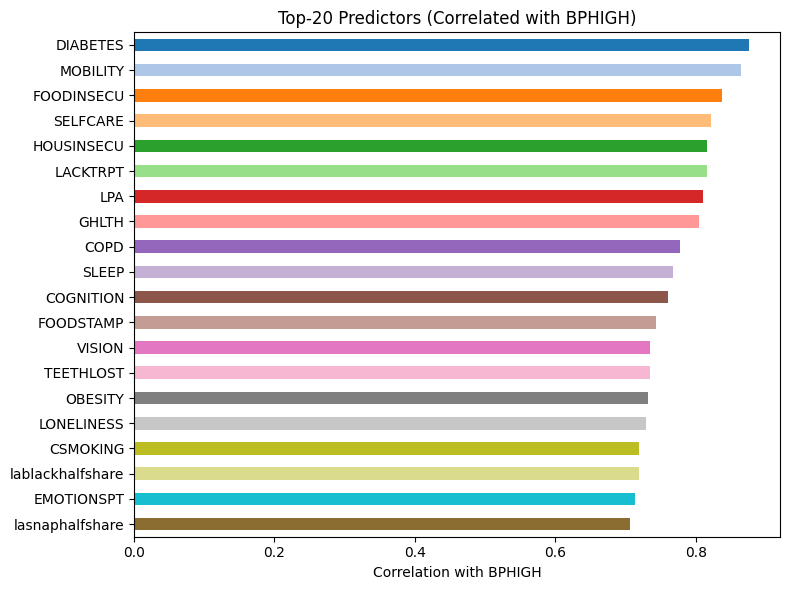

No leakage flags (|r| > 0.95).


In [37]:
# Generate Figure 3: Top 20 Correlations Bar Chart
corr = df.select_dtypes("number").corrwith(df[TARGET_COL]).drop(TARGET_COL).dropna()
top_20 = corr.reindex(corr.abs().sort_values(ascending=False).index).head(20)
top_20_sorted = top_20.sort_values()

bar_colors = [variable_color(feature) for feature in top_20_sorted.index]

fig2, ax2 = plt.subplots(figsize=(8, 6))
top_20_sorted.plot.barh(ax=ax2, color=bar_colors)
ax2.set_xlabel(f"Correlation with {TARGET_COL}")
ax2.set_title(f"Top-20 Predictors (Correlated with {TARGET_COL})")
plt.tight_layout()
    
plt.show()

# Check for potential data leakage
leaks = top_20[top_20.abs() > 0.95]
print("No leakage flags (|r| > 0.95)." if leaks.empty else leaks)

All top-20 predictors correlate positively with BPHIGH, led by DIABETES (r ≈ 0.88), MOBILITY (r ≈ 0.86), and FOODINSECU (r ≈ 0.84). Most come from the CDC comorbidity/SDoH cluster; only two USDA share variables make the list. Nothing exceeds the 0.95 leakage threshold — no exclusions needed.

Generating correlation heatmap matrix for top features and target variable.


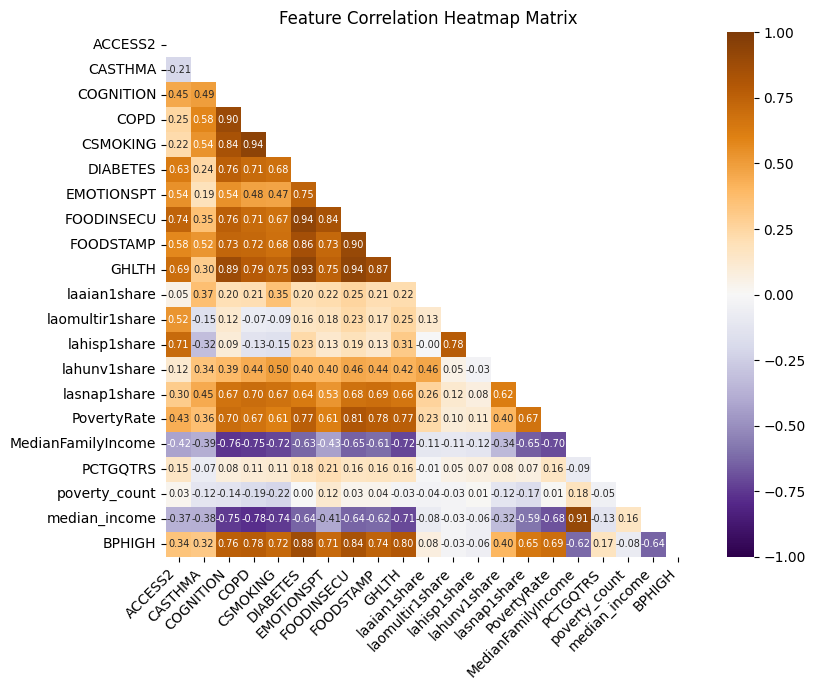

In [38]:
# Generate Figure 4: Correlation Heatmap Matrix
top_features = list(corr.head(10).index) + list(corr.tail(10).index) + [TARGET_COL]
corr_matrix = df[top_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

print("Generating correlation heatmap matrix for top features and target variable.")
fig3, ax3 = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            annot_kws={"size": 7},
            cmap="PuOr_r", vmin=-1, vmax=1, center=0, square=True, ax=ax3)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha="right")
ax3.set_title("Feature Correlation Heatmap Matrix")
plt.tight_layout()

plt.show()

The heatmap shows several groups of strongly related predictors. Median income and median family income are highly correlated at 0.91. Many demographic and food-access measures are also strongly correlated with one another, with some correlations above 0.90. The health and social-condition variables form another closely related group.

County hypertension prevalence (`BPHIGH`) has its strongest positive correlations with diabetes (0.88), mobility limitations (0.86), food insecurity (0.84), and several other health and social measures. In contrast, hypertension is negatively correlated with median income (-0.64) and median family income (-0.62), suggesting that counties with higher income generally have lower hypertension prevalence.

Overall, the heatmap shows substantial overlap among the predictors. This supports the use of Lasso and PCA to reduce repeated information and improve model stability. However, these correlations describe relationships between variables and do not prove that one variable causes another.


## 6. Feature Engineering

*For full details on Feature Engineering visit `notebooks/04_FeatureEngineering`*

### 6.1 Drop Missing Target Values
EDA found missing rows in the target variable `BPHIGH`, county-level hypertension prevalence from CDC PLACES. 2,956 of 3,231 counties (91.5%) have a usable target value; the remaining 275 (8.5%) will be dropped before model fitting, not imputed. This is the row count that carries forward into every later modeling step, not the full table size.

In [39]:
# Dropping rows with missing target values
# removing 275 counties (8.5%), leaving 2,956 counties for modeling.
TARGET_COL = "BPHIGH"
df.dropna(subset=[TARGET_COL], inplace=True)
df.shape

(2956, 120)

### 6.2 Feature Redundancy and Correlation

EDA found a redundent feature. USDA and Census independently estimate the same underlying quantity: county-level income through different methods (USDA's tract-population-weighted mean vs. Census's direct county-level ACS estimate).

The variables have a strong correlation of 0.91, which means that there is a high risk of multicollinearity if both are included in modeling
Since both sources are reputable, each likely contains a small amount of "unique" signal due to their different methodologies (tract-weighting vs. direct estimate). Instead of choosing one, create a "Consensus Income" variable. Retain all variables in the dataset and decide drop conditions after LASSO and PCA analysis. 

In [40]:
# Create the synthesized feature of median_income (from Census ACS Datasest) and MedianFamilyIncome (from USDA Food Access Dataset)
df['consensus_income'] = (df['median_income'] + df['MedianFamilyIncome']) / 2

# Now your DataFrame has three income-related columns:
# ['median_income', 'MedianFamilyIncome', 'consensus_income']
df.shape

(2956, 121)

### 6.3 Data Block Analysis: USDA la*/Tract* Family

EDA found that 77 of the 78 USDA la*/Tract* columns have a VIF above 10, and dozens reach the 10¹³–10¹⁵ range. Values that large don't mean the columns are merely correlated — they mean some columns can be computed almost exactly from others. That makes sense given how USDA builds this data: many share columns are literally a count column divided by a population column, and all three versions sit in our table. The takeaway is clear: these 92 columns cannot go into a model as 92 separate features. A linear model would produce wildly unstable coefficients.

In [41]:
# Assign columns to their source datasets for clarity
id_cols = ["fipscode", "locationname", "stateabbr", "State", "County"]
acs_cols = ["poverty_count", "median_income"]
cdc_cols = ["ACCESS2", "BPHIGH", "CASTHMA", "COGNITION", "COPD", "CSMOKING",
            "DIABETES", "EMOTIONSPT", "FOODINSECU", "FOODSTAMP", "GHLTH",
            "HOUSINSECU", "LACKTRPT", "LONELINESS", "LPA", "MOBILITY",
            "OBESITY", "SELFCARE", "SLEEP", "TEETHLOST", "VISION"]
usda_cols = [c for c in df.columns if c not in id_cols + acs_cols + cdc_cols]

### 6.4 Pruning: 

Perform a hard drop on the la* and Tract* family. For columns that are a Count and another that is a Percentage of the same population, keep the Percentage. Ratios are generally more stable and less prone to scaling issues than raw counts.

The dataset contains both raw counts and percetage share columns for the same population for almost every category. 
    **For example:**
    `lakidshalf`: Low access, children age 0-17 at 1/2 mile, number
    `lakidshalfshare`:Low access, children age 0-17 at 1/2 mile, share

All "number" columns should be dropped and all "share" columns should be retained. This is a hard drop, not a soft drop, because the number columns are redundant and will cause multicollinearity issues in modeling.

In [42]:
# identify the la_family columns that contain 'share' or 'Tract' in their names for further analysis
la_family = [c for c in df.columns if c.lower().startswith(("la", "tract"))]

In [43]:
# Define "keep" criteria
# Keep if it contains 'share' OR if it is a 'Tract' column (since these are counts 
# but are distinct from the 'la' counts), AND explicitly NOT a 'number' type.
# Note: Since column names contain 'number' as a suffix or indicator, 
# we exclude them.
la_family_refined = [
    col for col in la_family 
    if ('share' in col or 'Tract' in col) 
    and 'number' not in col.lower()
]

# Get list of columns to drop based on the refined criteria
la_cols_to_drop = [col for col in la_family if col not in la_family_refined]

# Perform the drop on the main dataframe
df = df.drop(columns=la_cols_to_drop)

# Verify the drop
print(f"Original la_family size: {len(la_family)}")
print(f"Refined la_family size: {len(la_family_refined)}")

Original la_family size: 79
Refined la_family size: 43


In [44]:
df.shape

(2956, 85)

> **⚠️ Note on Data Leakage Prevention & Feature Reduction**
> 
> * **Train-Test Split:** An 80/20 split was executed prior to feature reduction to isolate sequestered datasets for all downstream engineering, validation, and modeling.
> * **Scaling & Tuning:** Features were standardized using `StandardScaler` (since LASSO is scale-sensitive), and an optimal alpha of **0.0055** was determined via 5-fold cross-validation (`LassoCV`).
> * **PCA Sweet Spot:** Model performance saw a significant boost from 5 to 10 components and plateaued from 20 to 30. 
**15 components** was selected as the optimal sweet spot to capture the majority of predictive power efficiently.
>
> * **Global Pipeline Architecture:** While initial exploratory feature engineering tested a localized PCA block for `la_family`, the final pipeline transitions to a unified global preprocessing and tuning approach. This guarantees rigorous train-test isolation and complete reproducibility across all modeling iterations.
> * **Pipeline Integration:** Feature selection (LASSO with L1 regularization) and dimensionality reduction (PCA) were strictly integrated into modeling pipelines to prevent data leakage.


### 6.5 Load Training and Testing Sets

In [45]:
# Load train/test splits
X_train_path = DATA_FINAL / "X_train.csv"
X_test_path = DATA_FINAL / "X_test.csv"
y_train_path = DATA_FINAL / "y_train.csv"
y_test_path = DATA_FINAL / "y_test.csv"
    
for p in [X_train_path, X_test_path, y_train_path, y_test_path]:
    validate_and_alert(p, p.name, "Run Feature Engineering and Train-Test Split scripts.")
    
X_train = pd.read_csv(X_train_path)
X_test = pd.read_csv(X_test_path)
y_train = pd.read_csv(y_train_path).squeeze()
y_test = pd.read_csv(y_test_path).squeeze()

✅ Data found for X_train.csv. Proceeding...
✅ Data found for X_test.csv. Proceeding...
✅ Data found for y_train.csv. Proceeding...
✅ Data found for y_test.csv. Proceeding...


In [46]:
# Drop identifier columns from the training and testing sets
ID_COLS = ["fipscode", "locationname", "stateabbr", "State", "County"]
train_ids = X_train[ID_COLS].copy()
test_ids = X_test[ID_COLS].copy()

X_train_model = X_train.drop(columns=[c for c in ID_COLS if c in X_train.columns])
X_test_model = X_test.drop(columns=[c for c in ID_COLS if c in X_test.columns])
FEATURES = list(X_train_model.columns)

print(f"X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

X_train: (2364, 84)   y_train: (2364,)
X_test:  (592, 84)   y_test:  (592,)


## 7. Modeling & Evaluation (XGBoost, RF, & Baseline)

*For full details on Modeling visit `notebooks/05_Modeling`*

**Modeling Pipeline:** 

```
SimpleImputer(median) -> StandardScaler -> SelectFromModel(Lasso) -> PCA(15) -> regressor
```

| Step | Purpose |
| --- | --- |
| `imputer` | Fill the PLACES/USDA gaps without dropping counties |
| `scaler` | Put all predictors on a common scale — required before both Lasso and PCA |
| `feature_selection` | Lasso drives redundant coefficients to zero, dropping the noise columns |
| `pca` | Compress the surviving correlated predictors into 15 orthogonal components |
| `regressor` | The only step that varies between models |

In [47]:
# Assign Variables 
RANDOM_STAT = 42
CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STAT)

# Shared pipeline hyperparameters
LASSO_ALPHA = 0.0055
N_COMPONENTS = 15

# Color Palettes for consistency
VARIABLE_COLORS = {
    "individual_explained_variance": "#4e79a7",
    "cumulative_explained_variance": "#e15759",
    "reference": "#333333",
    "predicted_BPHIGH": "#2b6cb0",
    "residual": "#718096",
    "BPHIGH": "#e53e3e"
}

MODEL_COLORS = {
    "Linear Regression (baseline)": "#4e79a7",
    "Ridge": "#f28e2b",
    "ElasticNet": "#e15759",
    "SVR (RBF)": "#76b7b2",
    "Random Forest": "#59a14f",
    "XGBoost": "#edc948"
}

In [48]:
# Helper Functions

def make_pipeline(regressor, alpha=LASSO_ALPHA, n_components=N_COMPONENTS):
    """Build the agreed modeling pipeline with `regressor` at the final step."""
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("feature_selection", SelectFromModel(Lasso(alpha=alpha, max_iter=10000,
                                                    random_state=RANDOM_STAT))),
        ("pca", PCA(n_components=n_components, random_state=RANDOM_STAT)),
        ("regressor", regressor),
    ])

def score_row(y_true, y_pred, label):
    return {
        "Split": label,
        "R2": r2_score(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

In [49]:
# Run pipeline on baseline model (Linear Regression)
baseline_pipeline = make_pipeline(LinearRegression())
fitted_pre = baseline_pipeline.fit(X_train_model, y_train)
selector = fitted_pre.named_steps["feature_selection"]
pca = fitted_pre.named_steps["pca"]
selected = np.array(FEATURES)[selector.get_support()] 

baseline_pipeline

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


[Text(0.5, 0, 'Loading on PC1'), Text(0.5, 1.0, 'PC1 (34.4% of variance)')]

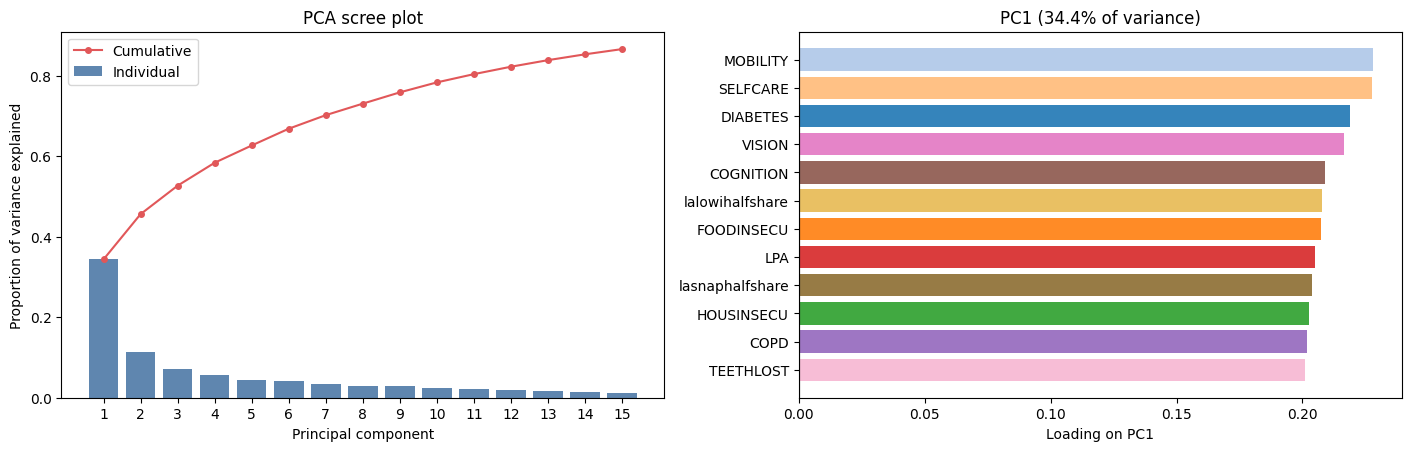

In [50]:
# PCA Structure Plot

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4), layout="constrained")
comps = np.arange(1, N_COMPONENTS + 1)
axes[0].bar(comps, pca.explained_variance_ratio_, color=VARIABLE_COLORS["individual_explained_variance"], alpha=0.9, label="Individual")
axes[0].plot(comps, np.cumsum(pca.explained_variance_ratio_), "o-", color=VARIABLE_COLORS["cumulative_explained_variance"],
            linewidth=1.5, markersize=4, label="Cumulative")
axes[0].set(xlabel="Principal component", ylabel="Proportion of variance explained", title="PCA scree plot", xticks=comps)
axes[0].legend()

loadings = pd.Series(pca.components_[0], index=selected).sort_values(key=abs, ascending=False)
top_load = loadings.head(12).iloc[::-1]
load_colors = [variable_color(feature) for feature in top_load.index]
axes[1].barh(top_load.index, top_load.values, color=load_colors, alpha=0.9)
axes[1].axvline(0, color=VARIABLE_COLORS["reference"], linewidth=0.8)
axes[1].set(xlabel="Loading on PC1", title=f"PC1 ({pca.explained_variance_ratio_[0]:.1%} of variance)")

The left graph shows that the first principal component explains 34.4% of the variance. Each additional component explains a smaller amount, while the cumulative line gradually reaches 86.6% at the fifteenth component.

The right graph shows that mobility, self-care, diabetes, vision, and cognition have the largest loadings on the first component. This suggests that the first component mainly summarizes a shared pattern across health, disability, and social-condition measures. However, PCA loadings describe how variables form a component; they do not show causal effects or individual feature importance.

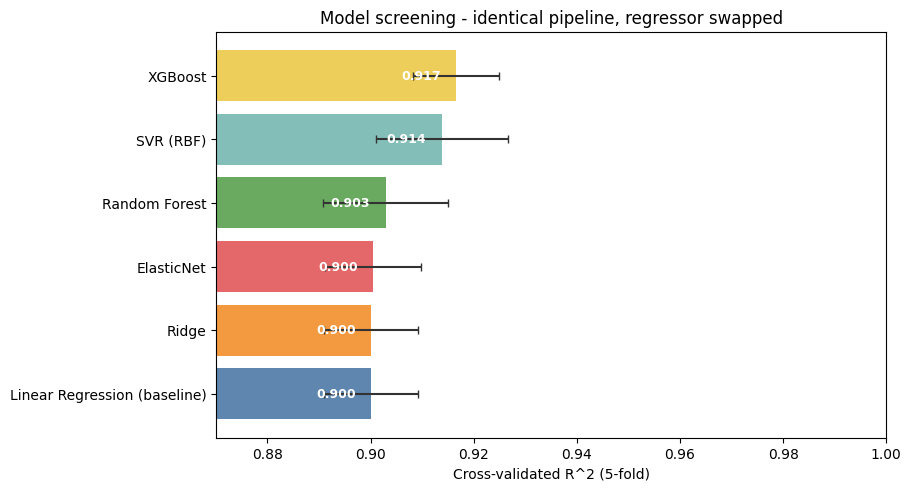

In [51]:
# Candidate Screening

candidates = {
    "Linear Regression (baseline)": make_pipeline(LinearRegression()),
    "Ridge": make_pipeline(Ridge(alpha=1.0, random_state=RANDOM_STAT)),
    "ElasticNet": make_pipeline(ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000, random_state=RANDOM_STAT)),
    "SVR (RBF)": make_pipeline(SVR(kernel="rbf", C=10.0, epsilon=0.1)),
    "Random Forest": make_pipeline(RandomForestRegressor(n_estimators=400, min_samples_leaf=2, random_state=RANDOM_STAT, n_jobs=1)),
    "XGBoost": make_pipeline(XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, tree_method="hist", random_state=RANDOM_STAT, n_jobs=1, verbosity=0)),
}

SCORING = {"r2": "r2", "rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error"}
rows = []
for name, pipe in candidates.items():
    scores = cross_validate(pipe, X_train_model, y_train, cv=CV, scoring=SCORING, n_jobs=1)
    rows.append({
        "Model": name,
        "R2 (mean)": scores["test_r2"].mean(),
        "R2 (sd)": scores["test_r2"].std(),
        "RMSE": -scores["test_rmse"].mean(),
        "MAE": -scores["test_mae"].mean(),
        "Fit time (s)": scores["fit_time"].mean(),
    })

cv_results = pd.DataFrame(rows).sort_values("R2 (mean)", ascending=False).reset_index(drop=True)
plot_df = cv_results.sort_values("R2 (mean)")

fig, ax = plt.subplots(figsize=(9, 4.8), layout="constrained")
bar_colors = [MODEL_COLORS.get(m, "#4e79a7") for m in plot_df["Model"]]
ax.barh(plot_df["Model"], plot_df["R2 (mean)"], xerr=plot_df["R2 (sd)"], color=bar_colors, alpha=0.9, error_kw={"ecolor": "#333333", "capsize": 3})
ax.set_xlabel("Cross-validated R^2 (5-fold)")
ax.set_title("Model screening - identical pipeline, regressor swapped")
ax.set_xlim(max(0.0, plot_df["R2 (mean)"].min() - 0.03), 1.0)
for y_pos, value in enumerate(plot_df["R2 (mean)"]):
    ax.text(value - 0.003, y_pos, f"{value:.3f}", va="center", ha="right", fontsize=9, color="white", fontweight="bold")
    

The figure compares the average five-fold cross-validated $R^2$ scores of the six models. XGBoost performed best, with an $R^2$ of 0.9166, which is 0.0165 higher than the linear regression baseline. SVR ranked a close second with an $R^2$ of 0.9138, followed by Random Forest at 0.9029. Elastic Net, Ridge, and linear regression produced similar scores of about 0.90. Although the error bars overlap, XGBoost achieved the highest average score and was selected for further tuning.

In [52]:
cv_results.round(4)

,Model,R2 (mean),R2 (sd),RMSE,MAE,Fit time (s)
0,XGBoost,0.9166,0.0083,1.3489,1.0381,0.4878
1,SVR (RBF),0.9138,0.0128,1.3726,1.0206,0.1437
2,Random Forest,0.9029,0.0122,1.4540,1.1158,3.5987
3,ElasticNet,0.9005,0.0094,1.4743,1.1569,0.0559
4,Ridge,0.9001,0.0091,1.4772,1.1571,0.0554
5,Linear Regression (baseline),0.9001,0.0091,1.4772,1.1571,0.0551


XGBoost achieved the highest average $R^2$ of 0.9166 and the lowest RMSE of 1.3489. It also had the smallest $R^2$ standard deviation of 0.0083, suggesting consistent performance across the five folds.

SVR ranked second with an average $R^2$ of 0.9138. It had the lowest MAE of 1.0206, meaning that its average prediction error was slightly smaller than that of XGBoost. Random Forest performed reasonably well but required the longest fitting time.

Elastic Net, Ridge, and the linear regression baseline had similar results, with average $R^2$ scores close to 0.90. Overall, XGBoost provided the best balance of predictive performance and consistency, so it was selected for further tuning.

In [53]:
best_name = cv_results.loc[0, "Model"]
baseline_r2 = cv_results.loc[cv_results["Model"].str.contains("baseline"), "R2 (mean)"].iloc[0]
print(f"Baseline (Linear Regression): CV R2 = {baseline_r2:.4f}")
print(f"Best candidate: {best_name} (CV R2 = {cv_results.loc[0, 'R2 (mean)']:.4f}, "
      f"{cv_results.loc[0, 'R2 (mean)'] - baseline_r2:+.4f} vs. baseline)")

Baseline (Linear Regression): CV R2 = 0.9001
Best candidate: XGBoost (CV R2 = 0.9166, +0.0165 vs. baseline)


In [54]:
# Hyperparameter Tuning

SHARED_GRIDS = [
    {"feature_selection__estimator__alpha": [0.0055, 0.01], "pca__n_components": [10, 15, 25]},
    {"feature_selection__estimator__alpha": [0.05], "pca__n_components": [10, 15, 20]},
]
REGRESSOR_GRIDS = {
    "Linear Regression (baseline)": {},
    "Ridge": {"regressor__alpha": [0.1, 1.0, 10.0]},
    "ElasticNet": {"regressor__alpha": [0.005, 0.01, 0.05], "regressor__l1_ratio": [0.2, 0.5, 0.8]},
    "SVR (RBF)": {"regressor__C": [1.0, 10.0, 50.0], "regressor__epsilon": [0.05, 0.1, 0.3]},
    "Random Forest": {"regressor__n_estimators": [400, 800], "regressor__min_samples_leaf": [1, 2, 5]},
    "XGBoost": {"regressor__learning_rate": [0.03, 0.05, 0.1], "regressor__n_estimators": [300, 600], "regressor__max_depth": [4, 6, 8]},
}

param_grid = [{**shared, **REGRESSOR_GRIDS[best_name]} for shared in SHARED_GRIDS]
grid = GridSearchCV(candidates[best_name], param_grid=param_grid, scoring="r2", cv=CV, n_jobs=1, refit=True, error_score="raise")
grid.fit(X_train_model, y_train)
best_model = grid.best_estimator_

y_pred_train = best_model.predict(X_train_model)
y_pred_test = best_model.predict(X_test_model)

baseline_fitted = make_pipeline(LinearRegression()).fit(X_train_model, y_train)
y_pred_baseline = baseline_fitted.predict(X_test_model)

final_scores = pd.DataFrame([
    score_row(y_train, y_pred_train, f"{best_name} - Train (In-sample)"),
    {"Split": f"{best_name} - Train (5-fold CV)", "R2": grid.best_score_, "RMSE": np.nan, "MAE": np.nan},
    score_row(y_test, y_pred_test, f"{best_name} - TEST (Held-out)"),
    score_row(y_test, y_pred_baseline, "Linear Regression Baseline - TEST (Held-out)"),
])

In [55]:
final_scores.round(4)

,Split,R2,RMSE,MAE
0,XGBoost - Train (In-sample),0.9831,0.6101,0.4710
1,XGBoost - Train (5-fold CV),0.9360,NaN,NaN
2,XGBoost - TEST (Held-out),0.9271,1.2117,0.9278
3,Linear Regression Baseline - TEST (Held-out),0.8959,1.4476,1.1200


In [56]:
print(f"\nTuned {best_name}")
for param, value in sorted(grid.best_params_.items()):
    print(f"  {param}: {value}")
print(f"Best cross-validated R2: {grid.best_score_:.4f}")


Tuned XGBoost
  feature_selection__estimator__alpha: 0.05
  pca__n_components: 20
  regressor__learning_rate: 0.03
  regressor__max_depth: 4
  regressor__n_estimators: 600
Best cross-validated R2: 0.9360


The best tuning result was achieved by XGBoost with a Lasso alpha of 0.05 and 20 PCA components. The final model used a learning rate of 0.03, a maximum tree depth of 4, and 600 trees. It achieved an average cross-validated ($R^2$) of 0.9360, meaning that the model explained about 93.6% of the variation in the outcome across the validation folds. 

The final XGBoost model achieved a test $R^2$ of 0.9271, meaning that it explained about 92.7% of the variation in the held-out data. Its test RMSE was 1.2117 and its MAE was 0.9278.

The test $R^2$ is lower than the training $R^2$of 0.9831 and slightly lower than the cross-validation $R^2$ of 0.9360. This suggests some overfitting, but the model still performs well on unseen data.

XGBoost also performed better than the linear regression baseline, which had a test $R^2$ of 0.8959, an RMSE of 1.4476, and an MAE of 1.1200. Overall, XGBoost explains more variation and produces smaller prediction errors, making it the stronger final model.

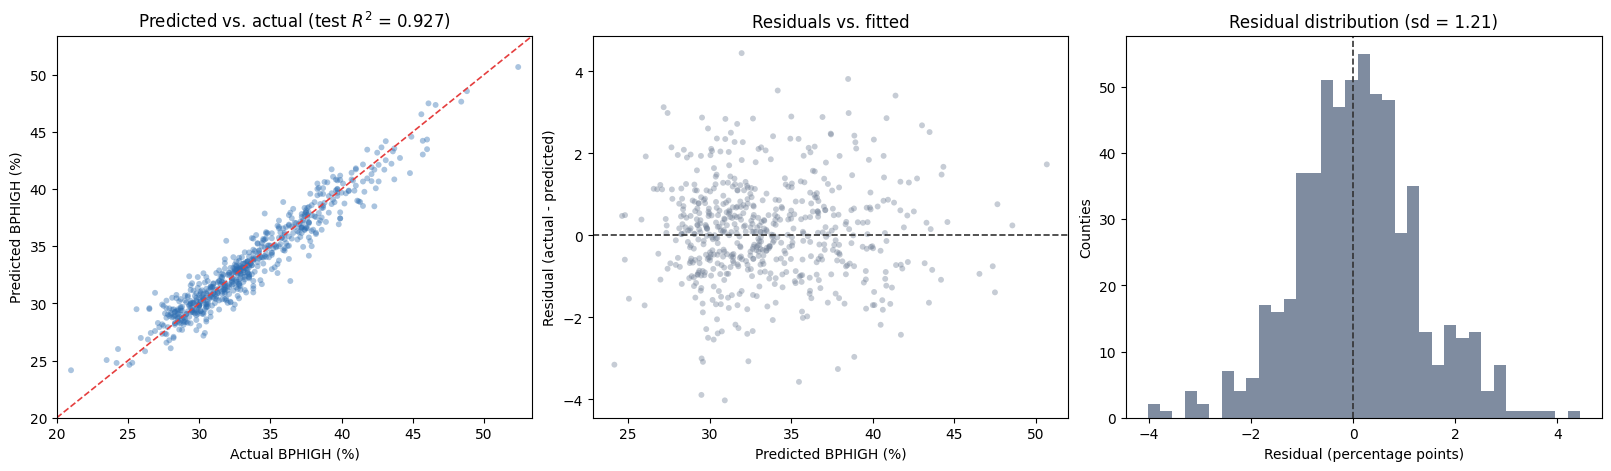

Counties predicted within 1 percentage point: 65.0%
Counties predicted within 2 percentage points: 88.9%


In [57]:
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), layout="constrained")

axes[0].scatter(y_test, y_pred_test, alpha=0.4, s=18, color=VARIABLE_COLORS["predicted_BPHIGH"], edgecolor="none")
lims = [min(y_test.min(), y_pred_test.min()) - 1, max(y_test.max(), y_pred_test.max()) + 1]
axes[0].plot(lims, lims, "--", color=VARIABLE_COLORS["BPHIGH"], linewidth=1.2)
axes[0].set(xlim=lims, ylim=lims, xlabel="Actual BPHIGH (%)", ylabel="Predicted BPHIGH (%)",
            title=f"Predicted vs. actual (test $R^2$ = {r2_score(y_test, y_pred_test):.3f})")

axes[1].scatter(y_pred_test, residuals, alpha=0.4, s=18, color=VARIABLE_COLORS["residual"], edgecolor="none")
axes[1].axhline(0, linestyle="--", color=VARIABLE_COLORS["reference"], linewidth=1.2)
axes[1].set(xlabel="Predicted BPHIGH (%)", ylabel="Residual (actual - predicted)",
            title="Residuals vs. fitted")

axes[2].hist(residuals, bins=35, color=VARIABLE_COLORS["residual"], alpha=0.9)
axes[2].axvline(0, linestyle="--", color=VARIABLE_COLORS["reference"], linewidth=1.2)
axes[2].set(xlabel="Residual (percentage points)", ylabel="Counties",
            title=f"Residual distribution (sd = {residuals.std():.2f})")

plt.show()

print(f"Counties predicted within 1 percentage point: {(residuals.abs() <= 1).mean():.1%}")
print(f"Counties predicted within 2 percentage points: {(residuals.abs() <= 2).mean():.1%}")

The left chart shows the predicted values are closely grouped around the 45-degree line, which agrees with the strong test `$R^2$` of 0.927. This means that the model’s predictions are generally close to the actual county values.

The center graph shows the residuals are mostly centered around zero and do not show a strong curve or funnel-shaped pattern. This suggests that the model does not have a major systematic bias and that its prediction errors are fairly consistent across the fitted range. However, a few larger errors are present, especially near the lowest and highest values.

The right graphic shows the residual distribution is also centered near zero, with a standard deviation of about 1.21 percentage points. Overall, 65.0% of counties are predicted within one percentage point of their actual value, while 88.9% are predicted within two percentage points. These results show that the final model provides accurate and reasonably consistent predictions for most counties.


## 8. SHAP Interpretability & Geographically Varying Drivers

PCA components are not interpretable in their own right, so importance is measured on the
**original predictors**: each raw column is shuffled and pushed through the entire fitted pipeline
(selection and PCA included), and the drop in test R² is recorded. This keeps the results in
feature space while respecting the pipeline actually being used.

Permutation importance is used to identify which original predictors contribute most to the final XGBoost model. Each feature is randomly shuffled, and the resulting decrease in test $R^2$ is measured. A larger decrease means that the model depends more strongly on that feature. The error bars show how much the importance score changes across repeated shuffles.

SHapley Additive exPlanations (SHAP) is a method used to explain why a machine learning model makes a particular prediction. It assigns each feature an importance value for a specific prediction, allowing us to understand the contribution of each feature to the model's output. Using SHAP bridges the performance and explainability gap, providing insights into the model's decision-making process, allowing for an understanding of the underlying drivers of hypertension prevalence.

In [58]:
# Run Permutation Importance first
perm = permutation_importance(best_model, X_test_model, y_test, n_repeats=15,
                              random_state=RANDOM_STAT, n_jobs=1, scoring="r2")

importance = (pd.DataFrame({"feature": FEATURES,
                            "importance": perm.importances_mean,
                            "std": perm.importances_std})
              .sort_values("importance", ascending=False)
              .reset_index(drop=True))

In [59]:
# SHAP values for the best model
# Define a background dataset for SHAP explainer.
background_data = X_train_model.sample(n=min(100, len(X_train_model)), random_state=42)

# Initialize SHAP Explainer using the pipeline's predict method.
explainer = shap.Explainer(best_model.predict, background_data)

# Calculate SHAP values for your test set (or evaluation set)
shap_values = explainer(X_test_model)

PermutationExplainer explainer: 593it [01:44,  5.29it/s]                         


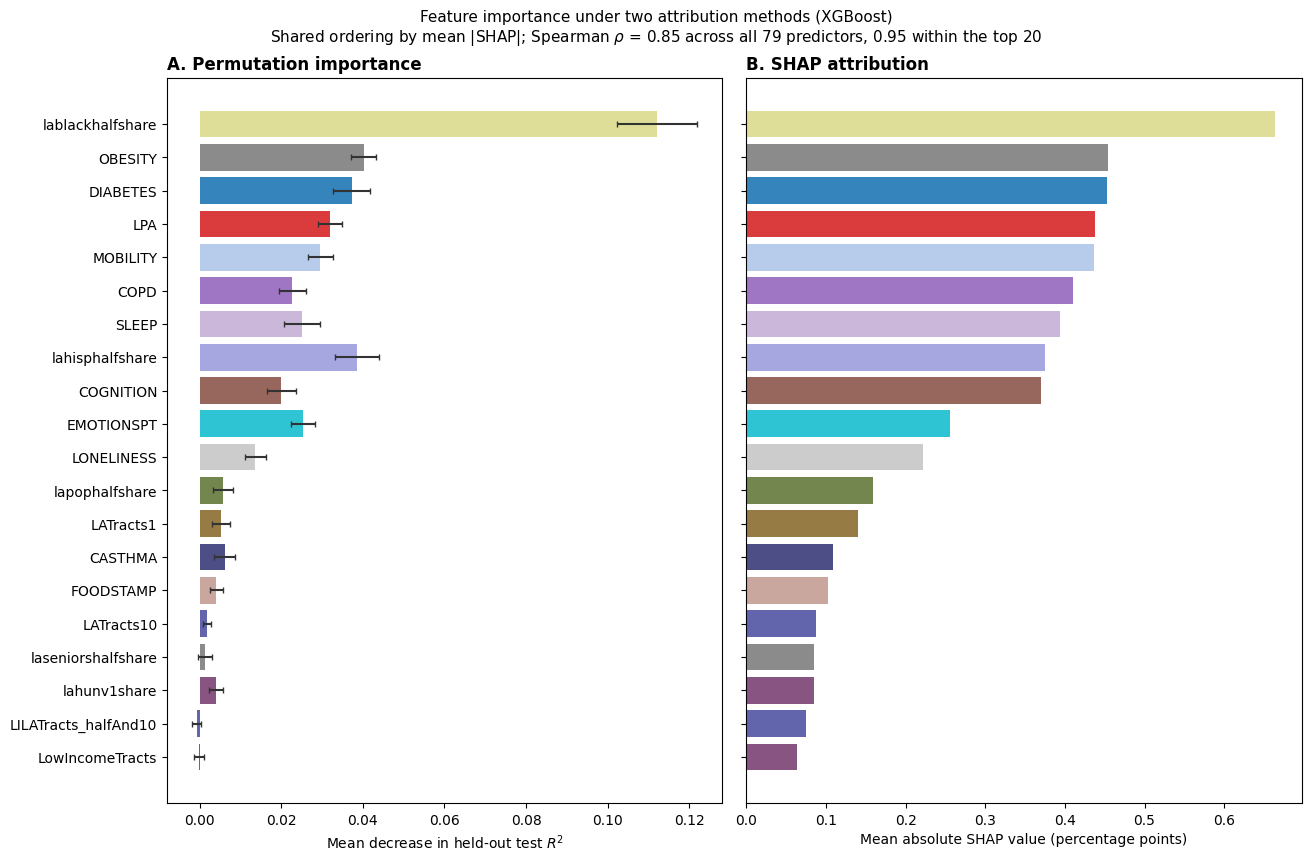

Spearman rank correlation, all predictors:  rho = 0.851  (p = 2.8e-23)
Spearman rank correlation, top 20:        rho = 0.953

Top-5 by each method:
         by SHAP   by permutation
lablackhalfshare lablackhalfshare
         OBESITY          OBESITY
        DIABETES  lahisphalfshare
             LPA         DIABETES
        MOBILITY              LPA


In [60]:
TOP_N = 20

# SHAP: mean absolute value per feature (recomputed here so the cell is standalone)
shap_imp = pd.Series(np.abs(shap_values.values).mean(axis=0),
                     index=list(X_test_model.columns))

# Permutation: from Section 7
perm_imp = importance.set_index("feature")["importance"]
perm_sd = importance.set_index("feature")["std"]

# Shared ordering, strongest at top
order = list(shap_imp.sort_values(ascending=False).head(TOP_N).index)
y = np.arange(len(order))[::-1]
colors = [variable_color(f) for f in order]

fig, axes = plt.subplots(1, 2, figsize=(13, 8.5), layout="constrained")

# --- left: permutation importance -------------------------------------------
axes[0].barh(y, perm_imp.reindex(order).to_numpy(),
             xerr=perm_sd.reindex(order).to_numpy(),
             color=colors, alpha=0.9,
             error_kw={"ecolor": "#333333", "capsize": 2})
axes[0].set_yticks(y, order)
axes[0].set_xlabel("Mean decrease in held-out test $R^2$")
axes[0].set_title("A. Permutation importance", loc="left", fontweight="bold")

# --- right: SHAP -------------------------------------------------------------
axes[1].barh(y, shap_imp.reindex(order).to_numpy(), color=colors, alpha=0.9)
axes[1].set_yticks(y, [])          # ordering is shared, so labels appear once
axes[1].set_xlabel("Mean absolute SHAP value (percentage points)")
axes[1].set_title("B. SHAP attribution", loc="left", fontweight="bold")

# --- rank agreement ----------------------------------------------------------
common = [f for f in shap_imp.index if f in perm_imp.index]
rho, p = spearmanr(shap_imp[common], perm_imp[common])
rho_top, _ = spearmanr(shap_imp[order], perm_imp.reindex(order))

fig.suptitle(f"Feature importance under two attribution methods ({best_name})\n"
             f"Shared ordering by mean |SHAP|; Spearman $\\rho$ = {rho:.2f} across all "
             f"{len(common)} predictors, {rho_top:.2f} within the top {TOP_N}",
             fontsize=11)

plt.show()

print(f"Spearman rank correlation, all predictors:  rho = {rho:.3f}  (p = {p:.1e})")
print(f"Spearman rank correlation, top {TOP_N}:        rho = {rho_top:.3f}")
print("\nTop-5 by each method:")
print(pd.DataFrame({
    "by SHAP": shap_imp.sort_values(ascending=False).head(5).index,
    "by permutation": perm_imp.sort_values(ascending=False).head(5).index,
}).to_string(index=False))

Features are ranked from top to bottom with the most impactful at the top. In this case lablackhalfshare is the top feature with a mean SHAP value over 0.6. The rest of the top five features are obesity, diabeties, mobility, and LPA with mean SHAP values between 0.4 and 0.5. The five features witht he lowest mean SHAP value are LowIncomeTracts, LILATracts_haldAnd10, Lahunv1share, LATracts10, and laseniorshalfshare, all of which have mean SHAP values under 0.1.

Feature lablackhalfshare is, on average, the strongest driver of model predictions, shifting the baseline estimate by the model's target units across counties.

## 9. Conclusion & Next Steps

An interactive Dashboard was created to visualize county-level hypertension prevalence, model predictions, and SHAP-driven feature importance. This dashboard enables public health officials and policymakers to explore the spatial distribution of hypertension risk and identify key structural drivers in their regions.

Access the live interactive deployment at <https://ads599capstonehypertensionriskatlas-3tepewveftselpfgfsn9nc.streamlit.app/>

To ensure usability for non-technical users, the dashboard utilized intuitive color-coded risk maps, interactive tooltips separating observed CDC baselines from model predictions, and responsive filters that keep interactions snappy across all counties. 

### 9.1 Limitations
* **Co-measured Data Dependency:** Headline performance relies on co-measured CDC PLACES estimates (Section 6.4). Where PLACES coverage is absent, the reduced-performance model acts as the more relevant benchmark.
* **Cross-Sectional Design:** Captures associations at a single point in time, precluding temporal or causal inferences (i.e., changing a predictor does not guarantee a change in prevalence).
* **Excluded Data:** County Health Rankings & Roadmaps data were dropped due to redundancy and missingness, leaving validated community-health measures unexploited.

### 9.2 Summary of Findings
* **Framework Objectives:** Integrated four federal county-level data sources, evaluated six regression models via a shared preprocessing pipeline, and deployed the winning model into an interactive atlas.
* **Performance & Qualification:** The tuned pipeline accurately prioritized high-risk communities in held-out counties, provided expectations are calibrated: accuracy depends on existing chronic-disease estimates, falling back to the reduced performance metric when PLACES data is missing.
* **Public Health Utility:** The atlas shifts public health planning from merely describing where hypertension is concentrated to pinpointing the underlying structural conditions accompanying that burden.


### 9.3 Recommendations for Future Work
1. **Analyze Spatial Non-Uniformity:** Group pre-computed per-county SHAP values by census region, state, and rural-urban stratum to test if hypertension drivers are spatially non-uniform.
2. **Implement Spatial Cross-Validation:** Replace random splits with spatial holdouts (withholding entire states/regions) to evaluate true out-of-sample deployment performance.
3. **Expand Model Comparisons:** Train tree-based models (XGBoost, Random Forest) directly on raw imputed features (bypassing standardization/PCA) and scale food-access analysis to the tract level.

**ACKNOWLEDGMENTS**
During the preparation of this work, the authors used Gemini, an AI-based large language model, to assist with initial research, the synthesis of the literature review, and the development of data ingestion strategies. After using this tool, the authors validated and edited all output content, including technical terminology and research summaries, to ensure accuracy and take full responsibility for the final content of the publication.
